# **Multiple Linear Regression**

## **Importing Libraries**

In [124]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , r2_score
from sklearn.metrics import mean_absolute_error



## **Loading Datasets**

In [125]:
df=pd.read_csv("Downloads/50_Startups.csv")
df

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [126]:
df.shape

(50, 5)

## **Data Preprocessing**

### Missing Values

In [127]:
df.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

There are no missing values

### Duplicate Values

In [128]:
df.duplicated().value_counts()

False    50
Name: count, dtype: int64

There are no duplicate values

### All columns except State contains numerical values. So change State column into numerical values like 0,1

In [129]:
df['california_state']=np.where(df['State']=='California',1,0)
df['Florida_state']=np.where(df['State']=='Florida',1,0)
df['Newyork_state']=np.where(df['State']=='New York',1,0)

### Dropping the State Column

In [130]:
df.drop(columns=['State'],axis=1,inplace=True)
df

,R&D Spend,Administration,Marketing Spend,Profit,california_state,Florida_state,Newyork_state
0,165349.20,136897.80,471784.10,192261.83,0,0,1
1,162597.70,151377.59,443898.53,191792.06,1,0,0
2,153441.51,101145.55,407934.54,191050.39,0,1,0
3,144372.41,118671.85,383199.62,182901.99,0,0,1
4,142107.34,91391.77,366168.42,166187.94,0,1,0
5,131876.90,99814.71,362861.36,156991.12,0,0,1
6,134615.46,147198.87,127716.82,156122.51,1,0,0
7,130298.13,145530.06,323876.68,155752.60,0,1,0
8,120542.52,148718.95,311613.29,152211.77,0,0,1
9,123334.88,108679.17,304981.62,149759.96,1,0,0


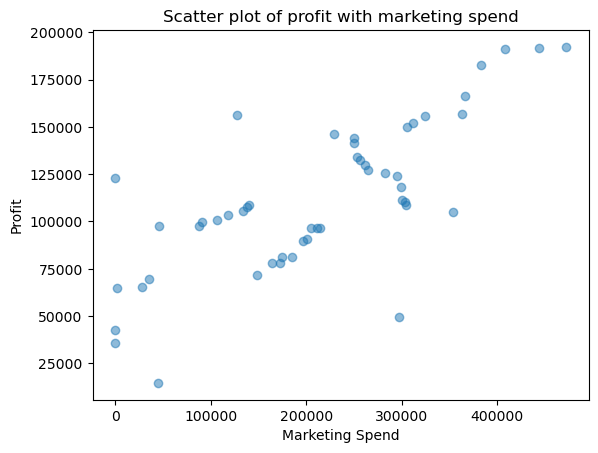

In [131]:
plt.scatter(df['Marketing Spend'],df['Profit'],alpha=0.5)
plt.title("Scatter plot of profit with marketing spend")
plt.xlabel("Marketing Spend")
plt.ylabel("Profit")
plt.show()

### Dependent & Independent Variables (X & Y)

In [132]:
dependent_variable='Profit'
independent_variable=list(set(df.columns.tolist()) - {dependent_variable})
independent_variable

['Administration',
 'R&D Spend',
 'Marketing Spend',
 'Florida_state',
 'Newyork_state',
 'california_state']

In [133]:
# create the data of independent variables
x=df[independent_variable].values

# create the dependent data variable
y=df[dependent_variable].values

df[independent_variable]

,Administration,R&D Spend,Marketing Spend,Florida_state,Newyork_state,california_state
0,136897.80,165349.20,471784.10,0,1,0
1,151377.59,162597.70,443898.53,0,0,1
2,101145.55,153441.51,407934.54,1,0,0
3,118671.85,144372.41,383199.62,0,1,0
4,91391.77,142107.34,366168.42,1,0,0
5,99814.71,131876.90,362861.36,0,1,0
6,147198.87,134615.46,127716.82,0,0,1
7,145530.06,130298.13,323876.68,1,0,0
8,148718.95,120542.52,311613.29,0,1,0
9,108679.17,123334.88,304981.62,0,0,1


In [134]:
# Splitting the dataset into the Training set and Test set
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [135]:
# Transforming data
scaler=MinMaxScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)





You use MinMaxScaler to normalize your data so that all features are on the same scale (0 to 1).

👉 This helps the model train faster and perform better, since no feature dominates due to larger numeric values.

## **Linear Regression**

In [136]:
# Model Training
model=LinearRegression()
model.fit(x_train_scaled,y_train)

# Model Prediction
y_pred=model.predict(x_test_scaled)

## **Model Evaluation**

In [137]:
print("Mean Squared Error : \n",mean_squared_error(y_test,y_pred))
print("R2 Score :\n",r2_score(y_test,y_pred))
print("Mean Absolute Error :\n",mean_absolute_error(y_test,y_pred))


Mean Squared Error : 
 82010363.04501352
R2 Score :
 0.8987266414319839
Mean Absolute Error :
 6961.477813275557
